# Data 3.4 / DATA1 — Modelagem Preditiva de Vendas para a Big Mart

Este Notebook desenvolve o desafio Data 3.4 / DATA1, com foco na previsão da variável `OutletSales`.



## 1. Resumo do desafio

A Big Mart deseja entender quais características dos produtos e das filiais influenciam as vendas e construir um modelo preditivo capaz de estimar o volume de vendas (`OutletSales`) de cada produto em uma loja.

O dataset contém dados de produtos e lojas, separados em arquivos de treino e teste.

## 2. Objetivos

- Carregar e compreender as bases de treino e teste.
- Preparar e sanear os dados.
- Tratar valores ausentes, inconsistências e anomalias.
- Realizar análise exploratória de dados.
- Construir visualizações claras e interpretáveis.
- Criar features úteis para modelagem.
- Treinar modelos supervisionados de regressão.
- Avaliar os modelos com métricas adequadas.
- Escolher e justificar o modelo final.
- Gerar predições para a base de teste.

## 3. Plano de execução

1. Configurar o ambiente e os caminhos do projeto.
2. Carregar `train.csv` e `test.csv`.
3. Validar estrutura, tipos de dados e presença da variável alvo.
4. Realizar diagnóstico inicial da qualidade dos dados.
5. Corrigir inconsistências conhecidas, especialmente em variáveis categóricas.
6. Tratar valores ausentes com técnicas adequadas por tipo de variável.
7. Criar features derivadas relevantes.
8. Conduzir a EDA com tabelas e gráficos.
9. Separar treino e validação.
10. Montar pipelines de pré-processamento e modelagem.
11. Treinar e comparar modelos de regressão.
12. Escolher o modelo final com base nas métricas.
13. Treinar o modelo final e gerar predições para o teste.
14. Salvar artefatos e conferir requisitos.

## 4. Configuração do ambiente e caminhos

O código abaixo foi escrito para funcionar tanto quando o Notebook é executado pela raiz do projeto quanto pela pasta `notebooks/`.

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"TRAIN_PATH existe? {TRAIN_PATH.exists()} -> {TRAIN_PATH}")
print(f"TEST_PATH existe? {TEST_PATH.exists()} -> {TEST_PATH}")

PROJECT_ROOT: C:\Users\gabri\Downloads\big-mart-data1-core\big-mart-data1-core
TRAIN_PATH existe? True -> C:\Users\gabri\Downloads\big-mart-data1-core\big-mart-data1-core\data\raw\train.csv
TEST_PATH existe? True -> C:\Users\gabri\Downloads\big-mart-data1-core\big-mart-data1-core\data\raw\test.csv


## 5. Importação das bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

## 6. Carregamento dos dados

In [3]:
train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)

print("Dimensão treino:", train_raw.shape)
print("Dimensão teste:", test_raw.shape)

display(train_raw.head())
display(test_raw.head())

Dimensão treino: (8523, 12)
Dimensão teste: (5681, 11)


,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType,OutletSales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


## 7. Padronização dos nomes das colunas

Os nomes originais são mantidos em formato mais legível para o relatório, mas internamente serão convertidos para `snake_case`, facilitando a manipulação e reduzindo erros de digitação.

In [4]:
def normalize_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.lower()
    )
    return df

train = normalize_column_names(train_raw)
test = normalize_column_names(test_raw)

display(train.head())
print(train.columns.tolist())

,productid,weight,fatcontent,productvisibility,producttype,mrp,outletid,establishmentyear,outletsize,locationtype,outlettype,outletsales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


['productid', 'weight', 'fatcontent', 'productvisibility', 'producttype', 'mrp', 'outletid', 'establishmentyear', 'outletsize', 'locationtype', 'outlettype', 'outletsales']


## 8. Validação da variável alvo

O desafio solicita a previsão de `OutletSales`. Após a normalização, essa variável passa a ser `outletsales`.

In [5]:
TARGET = "outletsales"

if TARGET not in train.columns:
    raise ValueError(f"A variável alvo esperada '{TARGET}' não foi encontrada na base de treino.")

print("Variável alvo encontrada:", TARGET)

Variável alvo encontrada: outletsales


## 9. Diagnóstico inicial da qualidade dos dados

In [6]:
print("Informações da base de treino:")
display(train.info())

print("\nValores ausentes no treino:")
display(train.isna().sum().sort_values(ascending=False))

print("\nValores ausentes no teste:")
display(test.isna().sum().sort_values(ascending=False))

print("\nDuplicidades no treino:", train.duplicated().sum())
print("Duplicidades no teste:", test.duplicated().sum())

display(train.describe(include="all").T)

Informações da base de treino:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   productid          8523 non-null   object 
 1   weight             7060 non-null   float64
 2   fatcontent         8523 non-null   object 
 3   productvisibility  8523 non-null   float64
 4   producttype        8523 non-null   object 
 5   mrp                8523 non-null   float64
 6   outletid           8523 non-null   object 
 7   establishmentyear  8523 non-null   int64  
 8   outletsize         6113 non-null   object 
 9   locationtype       8523 non-null   object 
 10  outlettype         8523 non-null   object 
 11  outletsales        8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


None


Valores ausentes no treino:


outletsize           2410
weight               1463
productid               0
fatcontent              0
productvisibility       0
producttype             0
mrp                     0
outletid                0
establishmentyear       0
locationtype            0
outlettype              0
outletsales             0
dtype: int64


Valores ausentes no teste:


outletsize           1606
weight                976
productid               0
fatcontent              0
productvisibility       0
producttype             0
mrp                     0
outletid                0
establishmentyear       0
locationtype            0
outlettype              0
dtype: int64


Duplicidades no treino: 0
Duplicidades no teste: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
productid,8523,1559,FDW13,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,7060.0,NaN,NaN,NaN,12.857645,4.643456,4.555,8.77375,12.6,16.85,21.35
fatcontent,8523,5,Low Fat,5089,NaN,NaN,NaN,NaN,NaN,NaN,NaN
productvisibility,8523.0,NaN,NaN,NaN,0.066132,0.051598,0.0,0.026989,0.053931,0.094585,0.328391
producttype,8523,16,Fruits and Vegetables,1232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mrp,8523.0,NaN,NaN,NaN,140.992782,62.275067,31.29,93.8265,143.0128,185.6437,266.8884
outletid,8523,10,OUT027,935,NaN,NaN,NaN,NaN,NaN,NaN,NaN
establishmentyear,8523.0,NaN,NaN,NaN,1997.831867,8.37176,1985.0,1987.0,1999.0,2004.0,2009.0
outletsize,6113,3,Medium,2793,NaN,NaN,NaN,NaN,NaN,NaN,NaN
locationtype,8523,3,Tier 3,3350,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 10. Limpeza e saneamento dos dados

Decisões adotadas:

- `fatcontent`: padronização de categorias equivalentes, como `LF`, `low fat` e `Low Fat`.
- `productvisibility`: valores iguais a zero são tratados como ausência latente, pois visibilidade nula para produto exposto em loja pode indicar problema de registro.
- `weight`: imputação posterior por mediana dentro do pipeline, evitando vazamento de dados.
- `outletsize`: imputação posterior por moda dentro do pipeline.
- Variáveis identificadoras (`productid`, `outletid`) são preservadas para referência, mas não usadas diretamente como preditores principais.

In [7]:
def clean_big_mart_dataframe(df):
    cleaned = df.copy()

    if "fatcontent" in cleaned.columns:
        cleaned["fatcontent"] = (
            cleaned["fatcontent"]
            .astype(str)
            .str.strip()
            .str.lower()
            .replace({
                "lf": "low fat",
                "low fat": "low fat",
                "reg": "regular",
                "regular": "regular"
            })
        )

    if "productvisibility" in cleaned.columns:
        cleaned["productvisibility"] = cleaned["productvisibility"].replace(0, np.nan)

    return cleaned

train_clean = clean_big_mart_dataframe(train)
test_clean = clean_big_mart_dataframe(test)

print("Categorias de fatcontent após padronização:")
display(train_clean["fatcontent"].value_counts(dropna=False))

Categorias de fatcontent após padronização:


fatcontent
low fat    5517
regular    3006
Name: count, dtype: int64

## 11. Engenharia de features

Foram criadas features simples e interpretáveis:

- `outlet_age`: idade da loja considerando 2013 como ano de referência do dataset Big Mart.
- `product_category`: categoria macro derivada dos dois primeiros caracteres do `productid`.
- `mrp_category`: faixa de preço do produto com base em quartis.

In [8]:
REFERENCE_YEAR = 2013

def add_features(df):
    featured = df.copy()

    if "establishmentyear" in featured.columns:
        featured["outlet_age"] = REFERENCE_YEAR - featured["establishmentyear"]

    if "productid" in featured.columns:
        featured["product_category"] = featured["productid"].astype(str).str[:2]

    if "mrp" in featured.columns:
        # qcut pode falhar em caso de muitos valores repetidos; duplicates='drop' evita esse problema.
        featured["mrp_category"] = pd.qcut(
            featured["mrp"],
            q=4,
            labels=False,
            duplicates="drop"
        ).astype("float")

    return featured

train_fe = add_features(train_clean)
test_fe = add_features(test_clean)

display(train_fe.head())

,productid,weight,fatcontent,productvisibility,producttype,mrp,outletid,establishmentyear,outletsize,locationtype,outlettype,outletsales,outlet_age,product_category,mrp_category
0,FDA15,9.30,low fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,14,FD,3.0
1,DRC01,5.92,regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,4,DR,0.0
2,FDN15,17.50,low fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,14,FD,1.0
3,FDX07,19.20,regular,NaN,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800,15,FD,2.0
4,NCD19,8.93,low fat,NaN,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,26,NC,0.0


## 12. Análise exploratória de dados — EDA

Nesta etapa, buscamos compreender padrões de venda, distribuição da variável alvo e relação entre atributos de produtos/lojas e `OutletSales`.

Resumo da variável alvo:


count     8523.000000
mean      2181.288914
std       1706.499616
min         33.290000
25%        834.247400
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: outletsales, dtype: float64

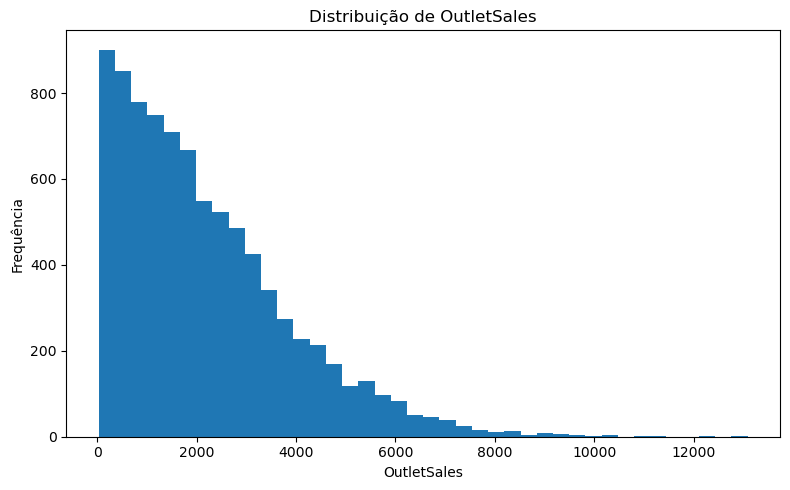

In [9]:
print("Resumo da variável alvo:")
display(train_fe[TARGET].describe())

plt.figure(figsize=(8, 5))
plt.hist(train_fe[TARGET], bins=40)
plt.title("Distribuição de OutletSales")
plt.xlabel("OutletSales")
plt.ylabel("Frequência")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "outletsales-distribution.png", dpi=150)
plt.show()

,outletsales
outletsales,1.000000
mrp,0.567574
mrp_category,0.543976
outlet_age,0.049135
weight,0.014123
establishmentyear,-0.049135
productvisibility,-0.138558


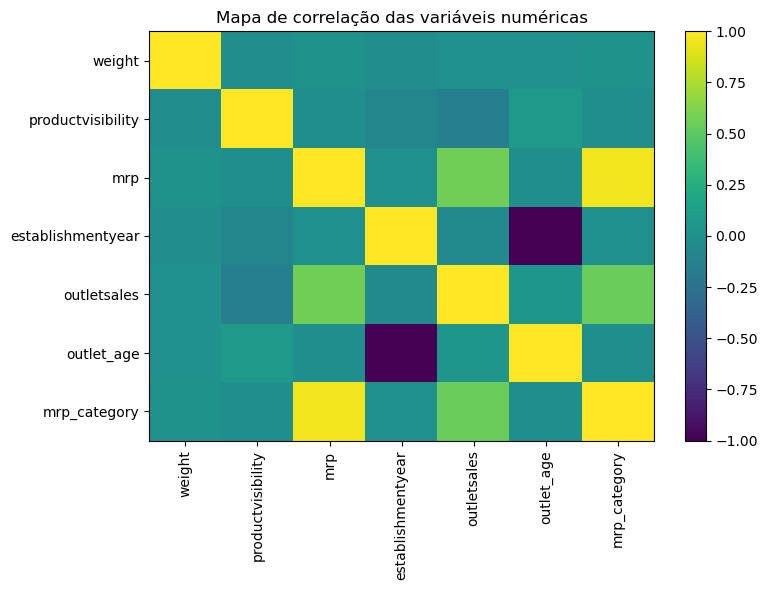

In [10]:
numeric_cols_for_corr = train_fe.select_dtypes(include=[np.number]).columns.tolist()
corr = train_fe[numeric_cols_for_corr].corr(numeric_only=True)

display(corr[[TARGET]].sort_values(by=TARGET, ascending=False))

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Mapa de correlação das variáveis numéricas")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "numeric-correlation-map.png", dpi=150)
plt.show()

producttype
Starchy Foods            2374.332773
Seafood                  2326.065928
Fruits and Vegetables    2289.009592
Snack Foods              2277.321739
Household                2258.784300
Dairy                    2232.542597
Canned                   2225.194904
Breads                   2204.132226
Meat                     2158.977911
Hard Drinks              2139.221622
Frozen Foods             2132.867744
Breakfast                2111.808651
Health and Hygiene       2010.000265
Soft Drinks              2006.511735
Baking Goods             1952.971207
Name: outletsales, dtype: float64

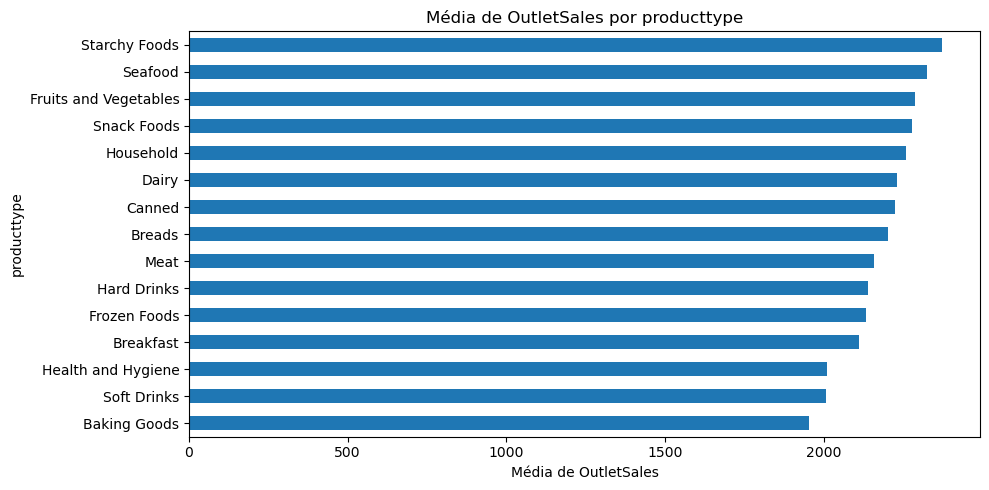

fatcontent
regular    2224.561170
low fat    2157.711534
Name: outletsales, dtype: float64

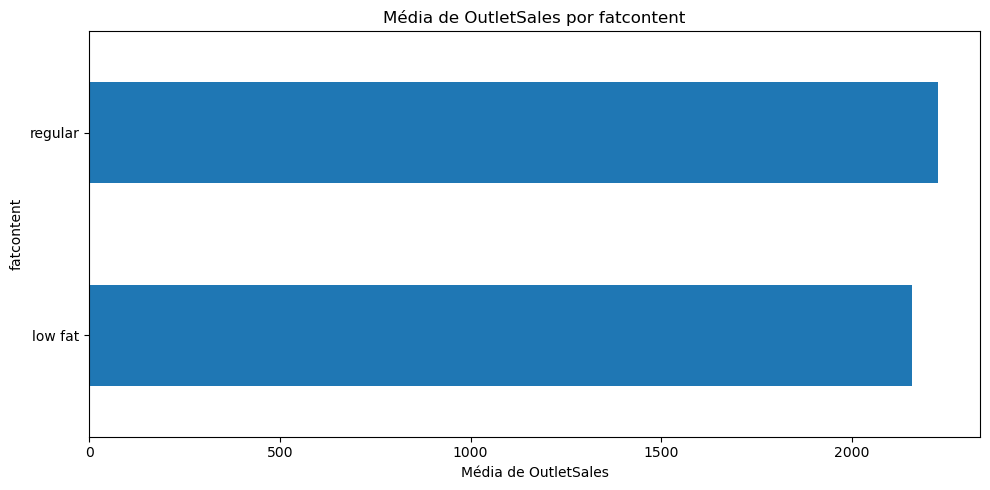

outletsize
Medium    2681.603542
High      2298.995256
Small     1912.149161
NaN       1822.626947
Name: outletsales, dtype: float64

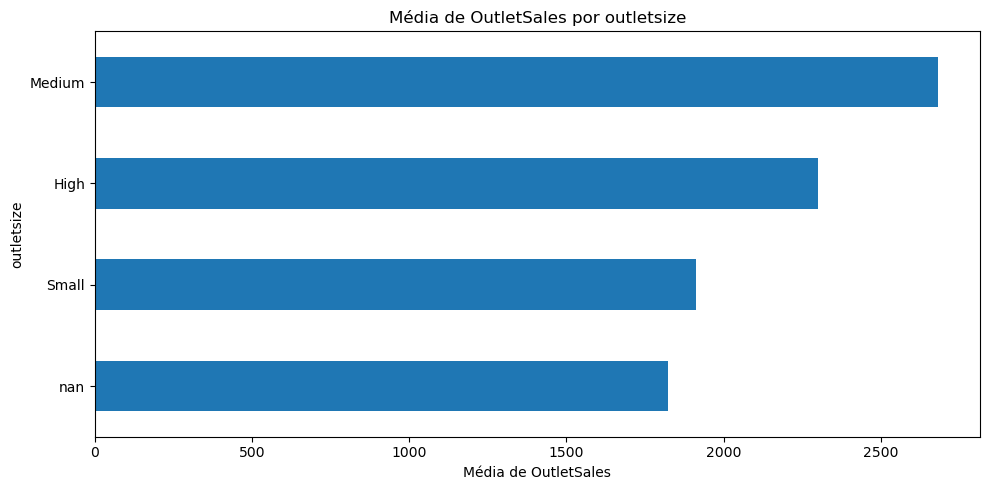

locationtype
Tier 2    2323.990559
Tier 3    2279.627651
Tier 1    1876.909159
Name: outletsales, dtype: float64

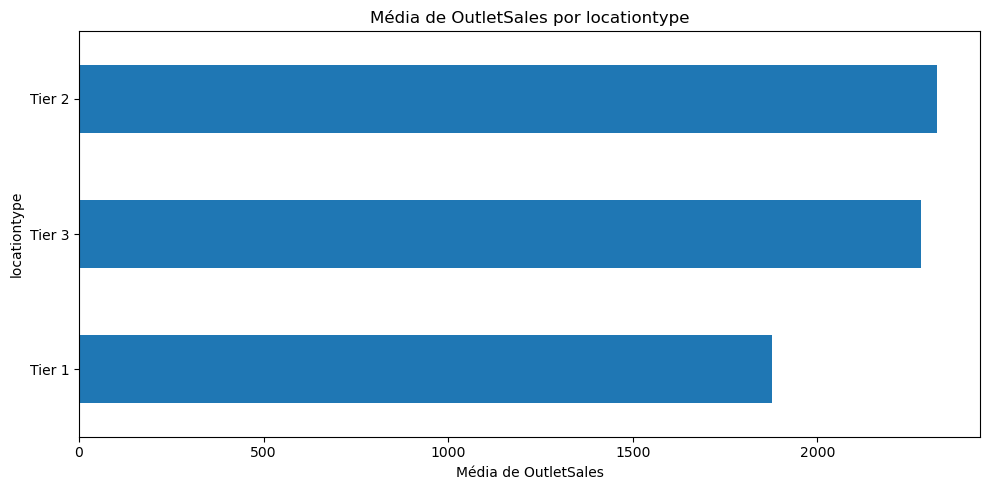

outlettype
Supermarket Type3    3694.038558
Supermarket Type1    2316.181148
Supermarket Type2    1995.498739
Grocery Store         339.828500
Name: outletsales, dtype: float64

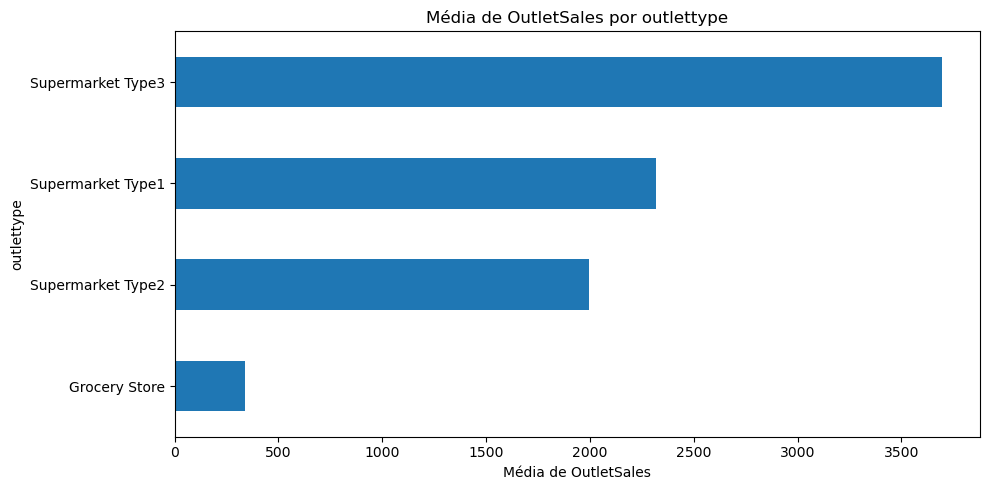

In [11]:
def plot_mean_sales_by_category(df, column, top_n=15):
    summary = (
        df.groupby(column, dropna=False)[TARGET]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
    )

    display(summary)

    plt.figure(figsize=(10, 5))
    summary.sort_values().plot(kind="barh")
    plt.title(f"Média de OutletSales por {column}")
    plt.xlabel("Média de OutletSales")
    plt.ylabel(column)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"mean-sales-by-{column}.png", dpi=150)
    plt.show()

for col in ["producttype", "fatcontent", "outletsize", "locationtype", "outlettype"]:
    if col in train_fe.columns:
        plot_mean_sales_by_category(train_fe, col)

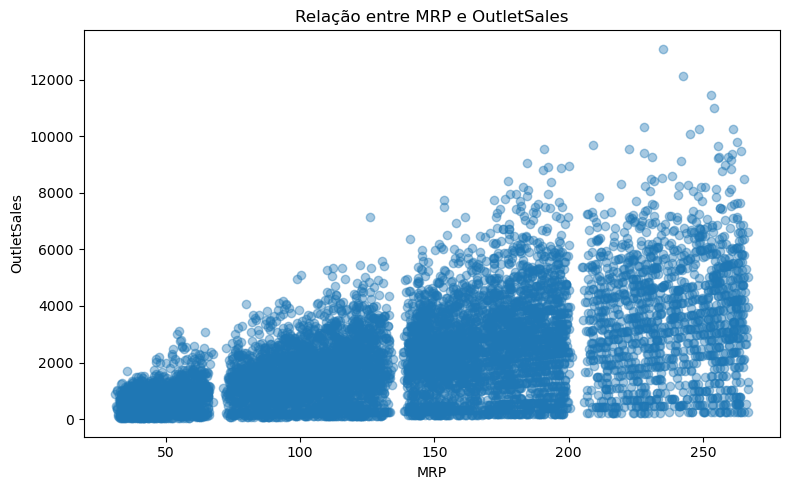

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(train_fe["mrp"], train_fe[TARGET], alpha=0.4)
plt.title("Relação entre MRP e OutletSales")
plt.xlabel("MRP")
plt.ylabel("OutletSales")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mrp-vs-outletsales.png", dpi=150)
plt.show()

## 13. Definição das variáveis de modelagem

As colunas `productid` e `outletid` são identificadores de alta cardinalidade. Para manter a solução mais generalizável e simples, elas não serão usadas diretamente como preditores. A informação de `productid` é parcialmente aproveitada pela feature `product_category`.

A variável alvo `outletsales` é removida de `X`.

In [13]:
id_columns = ["productid", "outletid"]
columns_to_drop = [TARGET] + [col for col in id_columns if col in train_fe.columns]

X = train_fe.drop(columns=columns_to_drop)
y = train_fe[TARGET].copy()

X_test_final = test_fe.drop(columns=[col for col in id_columns if col in test_fe.columns])

print("X:", X.shape)
print("y:", y.shape)
print("X_test_final:", X_test_final.shape)

display(X.head())

X: (8523, 12)
y: (8523,)
X_test_final: (5681, 12)


,weight,fatcontent,productvisibility,producttype,mrp,establishmentyear,outletsize,locationtype,outlettype,outlet_age,product_category,mrp_category
0,9.30,low fat,0.016047,Dairy,249.8092,1999,Medium,Tier 1,Supermarket Type1,14,FD,3.0
1,5.92,regular,0.019278,Soft Drinks,48.2692,2009,Medium,Tier 3,Supermarket Type2,4,DR,0.0
2,17.50,low fat,0.016760,Meat,141.6180,1999,Medium,Tier 1,Supermarket Type1,14,FD,1.0
3,19.20,regular,NaN,Fruits and Vegetables,182.0950,1998,NaN,Tier 3,Grocery Store,15,FD,2.0
4,8.93,low fat,NaN,Household,53.8614,1987,High,Tier 3,Supermarket Type1,26,NC,0.0


## 14. Separação entre treino e validação

A divisão treino/validação permite avaliar o desempenho em dados não vistos durante o treinamento.

In [14]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Treino:", X_train.shape)
print("Validação:", X_valid.shape)

Treino: (6818, 12)
Validação: (1705, 12)


## 15. Pipeline de pré-processamento

O pipeline evita vazamento de dados porque imputadores, escalonadores e codificadores são ajustados apenas sobre o conjunto de treino.

- Numéricas: imputação pela mediana e escalonamento.
- Categóricas: imputação pela moda e One-Hot Encoding.

In [15]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Variáveis numéricas:", numeric_features)
print("Variáveis categóricas:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Variáveis numéricas: ['weight', 'productvisibility', 'mrp', 'establishmentyear', 'outlet_age', 'mrp_category']
Variáveis categóricas: ['fatcontent', 'producttype', 'outletsize', 'locationtype', 'outlettype', 'product_category']


## 16. Treinamento e avaliação dos modelos

Serão comparados modelos supervisionados de regressão. As métricas utilizadas são:

- **RMSE**: penaliza erros maiores e é útil para medir erro médio na escala da variável.
- **MAE**: mede erro absoluto médio, sendo mais interpretável.
- **R²**: indica proporção da variância explicada pelo modelo.

In [16]:
models = {
    "linear_regression": LinearRegression(),
    "ridge": Ridge(alpha=1.0, random_state=42),
    "random_forest": RandomForestRegressor(
        n_estimators=250,
        random_state=42,
        n_jobs=-1,
        max_depth=8
    ),
    "gradient_boosting": GradientBoostingRegressor(
        random_state=42
    )
}

def evaluate_regression_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"rmse": rmse, "mae": mae, "r2": r2}

results = []
trained_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_valid)

    metrics = evaluate_regression_model(y_valid, predictions)
    metrics["model"] = model_name

    results.append(metrics)
    trained_pipelines[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values("rmse")
display(results_df)

,rmse,mae,r2,model
2,1028.034325,719.087530,0.611160,random_forest
3,1034.639076,721.373351,0.606148,gradient_boosting
0,1068.484578,791.278575,0.579959,linear_regression
1,1068.668081,791.361613,0.579815,ridge


## 17. Escolha do modelo final

O modelo final será escolhido pelo menor RMSE na validação, pois o RMSE penaliza erros grandes de previsão de vendas, o que é relevante para decisões de estoque e planejamento comercial.

In [17]:
best_model_name = results_df.iloc[0]["model"]
best_pipeline = trained_pipelines[best_model_name]

print(f"Modelo final escolhido: {best_model_name}")
display(results_df.iloc[[0]])

Modelo final escolhido: random_forest


,rmse,mae,r2,model
2,1028.034325,719.08753,0.61116,random_forest


## 18. Análise dos erros do modelo final

A comparação entre valores reais e previstos ajuda a verificar se o modelo apresenta tendência de superestimar ou subestimar as vendas.

,actual_outletsales,predicted_outletsales,error,absolute_error
count,1705.000000,1705.000000,1705.000000,1705.000000
mean,2097.008366,2120.354047,-23.345681,719.087530
std,1649.110402,1316.939774,1028.070743,734.904391
min,33.290000,58.172719,-3906.088415,1.138746
25%,772.328000,938.505536,-516.667456,188.504941
50%,1733.743200,2062.646728,-61.607738,484.505742
75%,2988.110400,3007.048485,440.140463,1005.357921
max,10236.675000,6781.025864,5721.784991,5721.784991


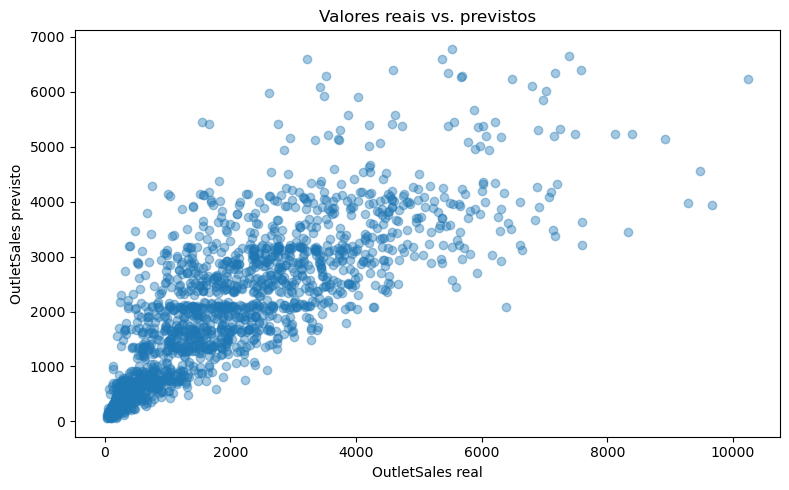

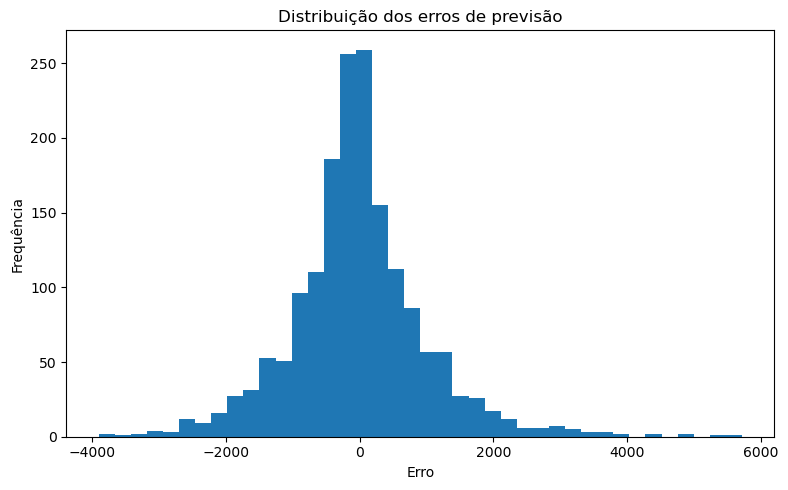

In [18]:
valid_predictions = best_pipeline.predict(X_valid)

error_analysis = pd.DataFrame({
    "actual_outletsales": y_valid,
    "predicted_outletsales": valid_predictions,
})
error_analysis["error"] = error_analysis["actual_outletsales"] - error_analysis["predicted_outletsales"]
error_analysis["absolute_error"] = error_analysis["error"].abs()

display(error_analysis.describe())

plt.figure(figsize=(8, 5))
plt.scatter(error_analysis["actual_outletsales"], error_analysis["predicted_outletsales"], alpha=0.4)
plt.title("Valores reais vs. previstos")
plt.xlabel("OutletSales real")
plt.ylabel("OutletSales previsto")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "actual-vs-predicted.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(error_analysis["error"], bins=40)
plt.title("Distribuição dos erros de previsão")
plt.xlabel("Erro")
plt.ylabel("Frequência")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "prediction-error-distribution.png", dpi=150)
plt.show()

## 19. Treinamento final e geração de predições para a base de teste

Após a escolha do modelo, ele é treinado novamente com toda a base de treino disponível e aplicado à base de teste.

In [19]:
final_model = models[best_model_name]

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", final_model)
])

final_pipeline.fit(X, y)

test_predictions = final_pipeline.predict(X_test_final)
test_predictions = np.maximum(test_predictions, 0)  # vendas negativas não fazem sentido de negócio

submission = test_fe.copy()
submission["predicted_outletsales"] = test_predictions

output_predictions_path = OUTPUT_DIR / "big_mart_test_predictions.csv"
submission.to_csv(output_predictions_path, index=False)

model_path = MODELS_DIR / "big_mart_model.joblib"
joblib.dump(final_pipeline, model_path)

print(f"Predições salvas em: {output_predictions_path}")
print(f"Modelo salvo em: {model_path}")

display(submission.head())

Predições salvas em: C:\Users\gabri\Downloads\big-mart-data1-core\big-mart-data1-core\outputs\big_mart_test_predictions.csv
Modelo salvo em: C:\Users\gabri\Downloads\big-mart-data1-core\big-mart-data1-core\outputs\models\big_mart_model.joblib


,productid,weight,fatcontent,productvisibility,producttype,mrp,outletid,establishmentyear,outletsize,locationtype,outlettype,outlet_age,product_category,mrp_category,predicted_outletsales
0,FDW58,20.750,low fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1,14,FD,1.0,1633.547296
1,FDW14,8.300,regular,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1,6,FD,0.0,1351.299372
2,NCN55,14.600,low fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store,15,NC,3.0,656.064999
3,FDQ58,7.315,low fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1,6,FD,2.0,2422.981731
4,FDY38,NaN,regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3,28,FD,3.0,6264.505939


## 20. Conclusão técnica

O projeto seguiu o ciclo básico de ciência de dados exigido no desafio:

- entendimento do problema;
- diagnóstico da base;
- limpeza e padronização;
- engenharia de features;
- análise exploratória;
- modelagem supervisionada;
- avaliação por métricas de regressão;
- seleção justificada do modelo;
- geração de artefatos finais.

O modelo escolhido deve ser interpretado como uma primeira versão funcional. Melhorias futuras poderiam incluir busca sistemática de hiperparâmetros, modelos avançados baseados em árvores e testes adicionais de estratégias de feature engineering.